Dataset description: .. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of dista ...
Training samples : 426
Testing samples  : 143


C:\Users\jeeva\AppData\Local\Temp\ipykernel_21868\161832107.py:42: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  knn.fit(X_train, y_train.ravel())  # .ravel() fixes the warning


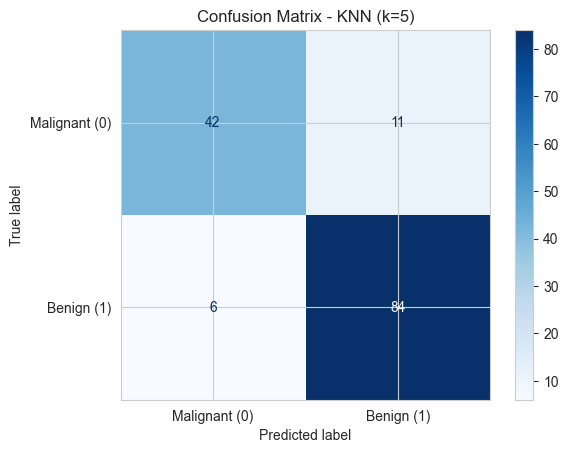

True Negatives  (correctly predicted Malignant): 42
False Positives (wrongly predicted Benign)     : 11
False Negatives (wrongly predicted Malignant)  : 6
True Positives  (correctly predicted Benign)   : 84


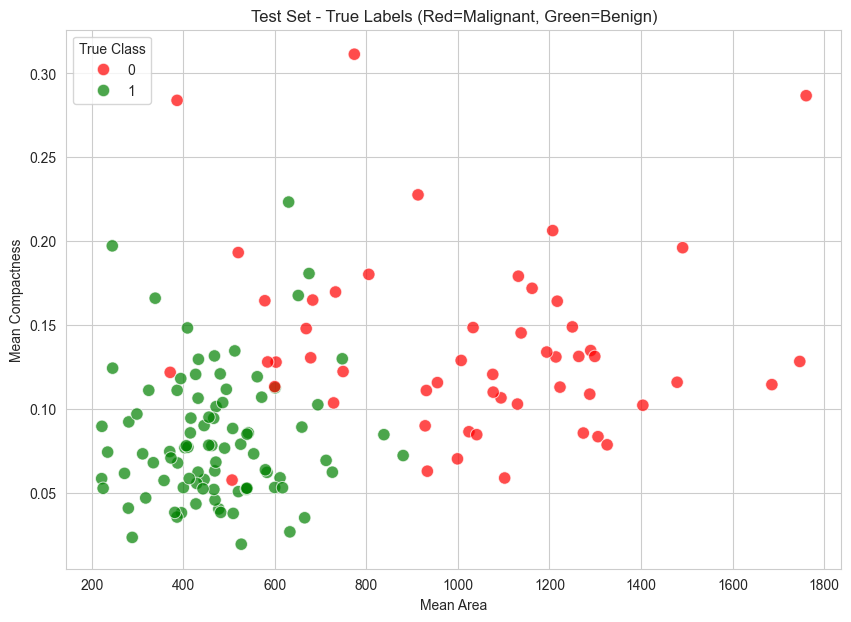

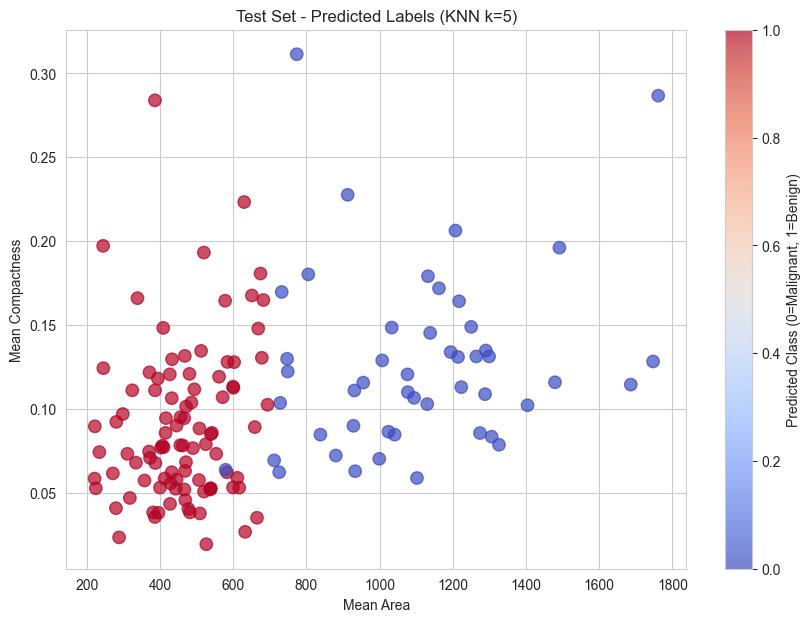

Accuracy on test set: 0.8811 (88.11%)


In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Set seaborn style for better visuals
sns.set_style("whitegrid")

# 1. Load the dataset
data = load_breast_cancer()
print("Dataset description:", data.DESCR[:300], "...")  # optional

# 2. Create feature DataFrame (using only two features for visualization)
df_features = pd.DataFrame(data.data, columns=data.feature_names)
X = df_features[["mean area", "mean compactness"]]

# 3. Prepare target (1 = benign, 0 = malignant)
y = pd.Series(data.target, name="target")  # 0=malignant, 1=benign

# 4. Train-test split (random_state for reproducibility)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=1,
    stratify=y
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")

# 5. Train KNN model
knn = KNeighborsClassifier(
    n_neighbors=5,
    metric="euclidean",
    weights="uniform"
)
knn.fit(X_train, y_train.ravel())  # .ravel() fixes the warning

# 6. Predict on test set
y_pred = knn.predict(X_test)

# 7. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Better way: use ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Malignant (0)", "Benign (1)"]
)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - KNN (k=5)")
plt.show()

# Manual extraction of metrics
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly predicted Malignant): {tn}")
print(f"False Positives (wrongly predicted Benign)     : {fp}")
print(f"False Negatives (wrongly predicted Malignant)  : {fn}")
print(f"True Positives  (correctly predicted Benign)   : {tp}")

# 8. Visualization: Scatter plot of test data with true labels
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pd.concat([X_test.reset_index(drop=True), y_test.reset_index(drop=True)], axis=1),
    x="mean area",
    y="mean compactness",
    hue="target",
    palette={0: "red", 1: "green"},
    alpha=0.7,
    s=80
)
plt.title("Test Set - True Labels (Red=Malignant, Green=Benign)")
plt.xlabel("Mean Area")
plt.ylabel("Mean Compactness")
plt.legend(title="True Class")
plt.show()

# 9. Visualization: Scatter plot with predicted labels
plt.figure(figsize=(10, 7))
plt.scatter(
    X_test["mean area"],
    X_test["mean compactness"],
    c=y_pred,
    cmap="coolwarm",
    alpha=0.7,
    s=80
)
plt.title("Test Set - Predicted Labels (KNN k=5)")
plt.xlabel("Mean Area")
plt.ylabel("Mean Compactness")
plt.colorbar(label="Predicted Class (0=Malignant, 1=Benign)")
plt.show()

# 10. Optional: Accuracy
accuracy = (tp + tn) / (tp + tn + fp + fn)
print(f"Accuracy on test set: {accuracy:.4f} ({accuracy*100:.2f}%)")

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
sns.set_style("whitegrid")

In [3]:
data = load_breast_cancer()

In [4]:
df_features = pd.DataFrame(data.data, columns=data.feature_names)
X = df_features[["mean area", "mean compactness"]]
y = pd.Series(data.target, name="target")

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=1,
    stratify=y
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")

Training samples : 426
Testing samples  : 143


In [6]:
knn = KNeighborsClassifier(n_neighbors=5, metric="euclidean", weights="uniform")
knn.fit(X_train, y_train.ravel())

C:\Users\jeeva\AppData\Local\Temp\ipykernel_11192\3799313433.py:2: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  knn.fit(X_train, y_train.ravel())


KNeighborsClassifier(metric='euclidean')

In [8]:
y_pred = knn.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

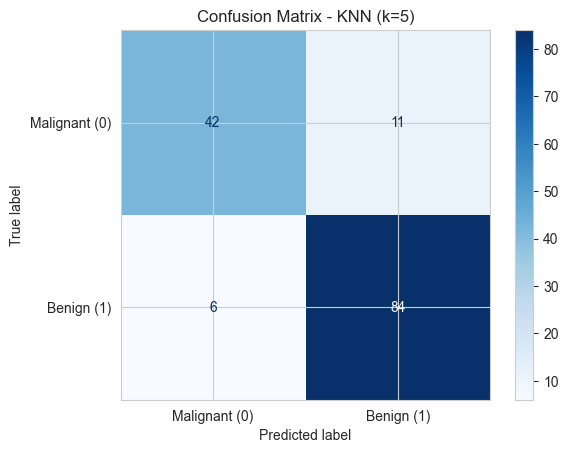

In [9]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Malignant (0)", "Benign (1)"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - KNN (k=5)")
plt.show()

In [10]:
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly predicted Malignant): {tn}")
print(f"False Positives (wrongly predicted Benign)     : {fp}")
print(f"False Negatives (wrongly predicted Malignant)  : {fn}")
print(f"True Positives  (correctly predicted Benign)   : {tp}")

True Negatives  (correctly predicted Malignant): 42
False Positives (wrongly predicted Benign)     : 11
False Negatives (wrongly predicted Malignant)  : 6
True Positives  (correctly predicted Benign)   : 84


<Axes: xlabel='mean area', ylabel='mean compactness'>

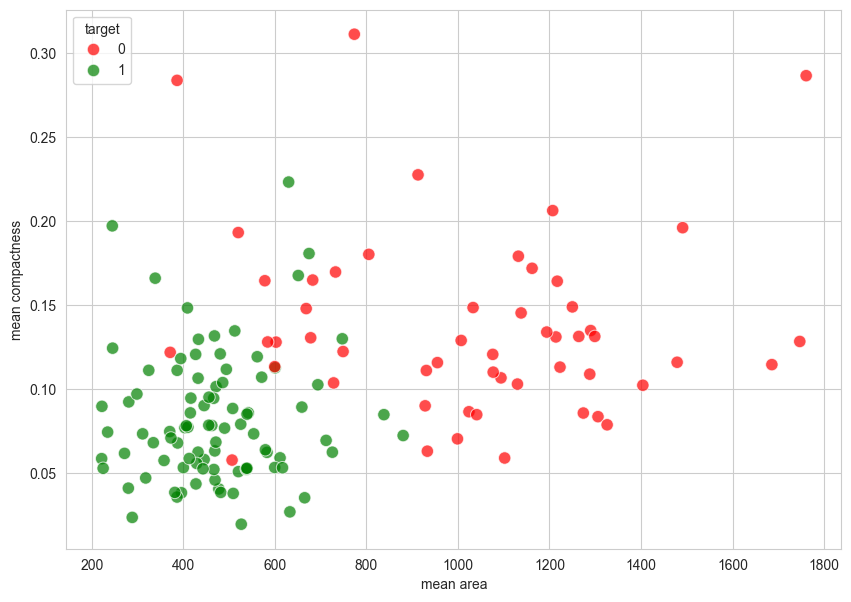

In [11]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pd.concat([X_test.reset_index(drop=True), y_test.reset_index(drop=True)], axis=1),
    x="mean area",
    y="mean compactness",
    hue="target",
    palette={0: "red", 1: "green"},
    alpha=0.7,
    s=80
)

C:\Users\jeeva\AppData\Local\Temp\ipykernel_11192\59796526.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="True Class")


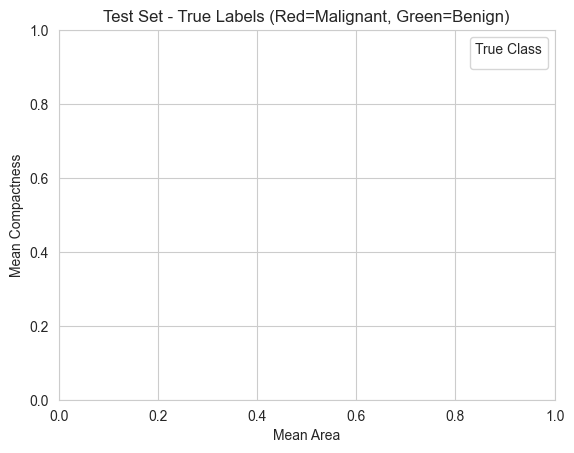

In [12]:
plt.title("Test Set - True Labels (Red=Malignant, Green=Benign)")
plt.xlabel("Mean Area")
plt.ylabel("Mean Compactness")
plt.legend(title="True Class")
plt.show()

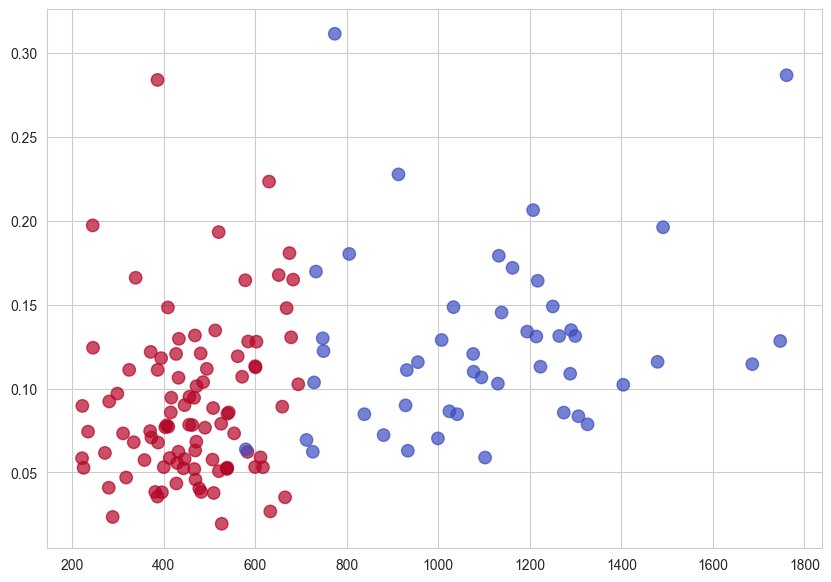

In [15]:
plt.figure(figsize=(10, 7))
sc = plt.scatter(
    X_test["mean area"],
    X_test["mean compactness"],
    c=y_pred,
    cmap="coolwarm",
    alpha=0.7,
    s=80
)

C:\Users\jeeva\AppData\Local\Temp\ipykernel_11192\1598438060.py:4: UserWarning: Adding colorbar to a different Figure <Figure size 1000x700 with 2 Axes> than <Figure size 640x480 with 1 Axes> which fig.colorbar is called on.
  plt.colorbar(sc, label="Predicted Class (0=Malignant, 1=Benign)")


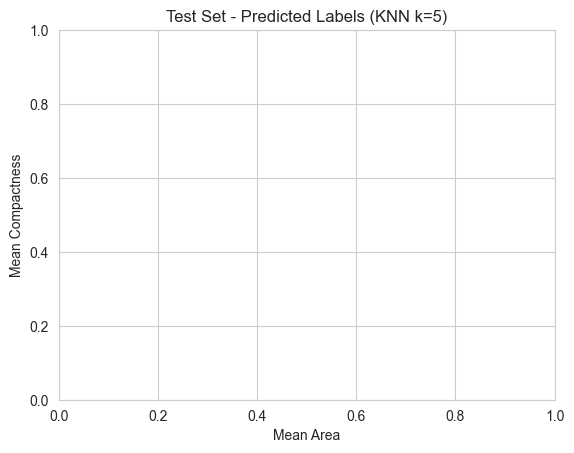

In [16]:
plt.title("Test Set - Predicted Labels (KNN k=5)")
plt.xlabel("Mean Area")
plt.ylabel("Mean Compactness")
plt.colorbar(sc, label="Predicted Class (0=Malignant, 1=Benign)")
plt.show()

In [17]:
accuracy = (tp + tn) / (tp + tn + fp + fn)
print(f"Accuracy on test set: {accuracy:.4f} ({accuracy*100:.2f}%)")

Accuracy on test set: 0.8811 (88.11%)
